# Table of Contents

### 1. Importing libraries and data
### 2. Data Cleaning and Wrangling
### 3. Reshaping for Modeling
### 4. Splitting the data
### 5. Optimizing Hyperparameters
### 6. Running Random Forest with New Parameters
### 7. Feature Importances

# 1. Importing libraries and data

In [7]:
# Importing libraries and data

import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [9]:
# Identifying a path to where data is stored

path = 'C:/Users/andyc/Machine Learning - ClimateWins'

In [11]:
# Importing the cleaned weather data set

cleancw = pd.read_csv(os.path.join(path, 'Data Sets', 'cleaned_weather.csv'), index_col = False)

In [13]:
# Importing the pleasant_weather data set

pleasant = pd.read_csv(os.path.join(path, 'Data Sets', 'Dataset-Answers-Weather_Prediction_Pleasant_weather.csv'), index_col = False)

In [15]:
cleancw.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,19600102,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,19600103,1,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,19600104,1,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,19600105,1,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [17]:
cleancw.shape

(22950, 137)

In [19]:
pleasant.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [21]:
pleasant.shape

(22950, 16)

# 2. Data Cleaning and Wrangling

In [32]:
# Filtering the cleaned weather dataset to the 2010s

cw_2010 = cleancw[cleancw['DATE'].astype(str).str.startswith('201')] 

cw_2010.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
18263,20100101,1,8,0.93,0.9965,0.18,0.56,0.0,2.9,-0.2,...,-7.0,1,0.80,1.0121,0.43,0.00,6.0,1.7,-1.6,5.0
18264,20100102,1,3,0.74,1.0193,0.58,0.00,5.2,-1.5,-4.2,...,-7.1,1,0.82,1.0196,0.45,0.00,6.0,0.8,-4.5,6.2
18265,20100103,1,3,0.75,1.0226,0.61,0.00,6.3,-3.2,-6.0,...,-7.1,4,0.71,1.0196,0.36,0.41,1.6,0.5,-4.1,5.1
18266,20100104,1,5,0.83,1.0169,0.48,0.00,3.7,-4.9,-8.3,...,-3.6,2,0.67,1.0219,0.48,0.51,6.5,3.7,1.3,3.8
18267,20100105,1,7,0.78,1.0073,0.53,0.04,4.4,-4.0,-7.1,...,-5.5,4,0.78,1.0117,0.45,0.09,4.7,2.3,-0.7,5.4


In [34]:
cw_2010.shape

(3652, 137)

In [28]:
# Filtering the pleasant dataset to the 2010s

pleasant_2010 = pleasant[pleasant['DATE'].astype(str).str.startswith('201')] 

pleasant_2010.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18263,20100101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18264,20100102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18265,20100103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18266,20100104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18267,20100105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [30]:
pleasant_2010.shape

(3652, 16)

In [36]:
# Dropping the 'DATE' and 'MONTH' columns from cleaned_2010 dataset

clean_2010 = cw_2010.drop(columns=['DATE', 'MONTH'])

In [38]:
clean_2010.shape

(3652, 135)

In [40]:
# Dropping the 'DATE' column from the pleasant_2010 dataset

clean_pleasant_2010 = pleasant_2010.drop(columns=['DATE'])

In [42]:
clean_pleasant_2010.shape

(3652, 15)

# 3. Reshaping for Modeling

In [45]:
X = clean_2010
y = clean_pleasant_2010

In [47]:
# Turning X and y from dataframes to arrays

X = np.array(X)
y = np.array(y)

In [49]:
X.shape

(3652, 135)

In [51]:
y.shape

(3652, 15)

# 4. Splitting the data

In [54]:
# Splitting the data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 28)

In [56]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2739, 135) (2739, 15)
(913, 135) (913, 15)


# 5. Optimizing Hyperparamaters

### Grid Search

In [60]:
# Creating a Random Forest classifier

clf = RandomForestClassifier()

In [62]:
# Grid search cv

grid_space={'max_depth':[3,5,10,None],
              'n_estimators':[10,100,200],
              'max_features':[15, 50, 100, 135], 
              'min_samples_leaf':[1,2,3],
              'min_samples_split':[1,2,3]
           }

In [66]:
start = time.time()
grid = GridSearchCV(clf, param_grid=grid_space, cv=3, scoring='accuracy', verbose=3, n_jobs=-2)
model_grid = grid.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


C:\Users\andyc\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
432 fits failed out of a total of 1296.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
432 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\andyc\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\andyc\anaconda3\Lib\site-packages\sklearn\base.py", line 1467, in wrapper
    estimator._validate_params()
  File "C:\Users\andyc\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\andyc\anaconda3\Lib\site-packa

Search took 4.670496900876363 minutes


In [68]:
print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

Best GRID search hyperparameters are: {'max_depth': None, 'max_features': 50, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 200}
Best GRID search score is: 0.6294267981014968


### Random Search

In [71]:
# Defining random search cv

rs_space={'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 500, step=50),
              'max_features':randint(15, 135),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1,4),
              'min_samples_split':np.arange(2, 10, step=2)
         }

In [73]:
# Creating a Random Forest classifier

clf2= RandomForestClassifier()

In [75]:
start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=10, scoring='accuracy', verbose=3, n_jobs=-2, cv=3)
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Search took 2.1241299788157146 minutes


In [77]:
# Printing Random Search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': 50, 'max_features': 65, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 110}
Best RANDOM search score is: 0.6283315078495801


In [79]:
# Comparing both searches

# Grid search results 

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

# Random random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best GRID search hyperparameters are: {'max_depth': None, 'max_features': 50, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 200}
Best GRID search score is: 0.6294267981014968
Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': 50, 'max_features': 65, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 110}
Best RANDOM search score is: 0.6283315078495801


GRID search is slightly better in terms of search score.

# 6. Running Random Forest with New Parameters

In [83]:
# Creating a Random Forst classifier with the best results

clf3 = RandomForestClassifier(n_estimators = 200, max_depth=None, max_features=50, min_samples_leaf=1, min_samples_split=3)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters

clf3.fit(X_train, y_train)

RandomForestClassifier(max_features=50, min_samples_split=3, n_estimators=200)

In [85]:
# Performing the predictions on the test dataset

y_pred = clf3.predict(X_test)
  
# Using the metrics module for accuracy calculation

print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  0.6987951807228916


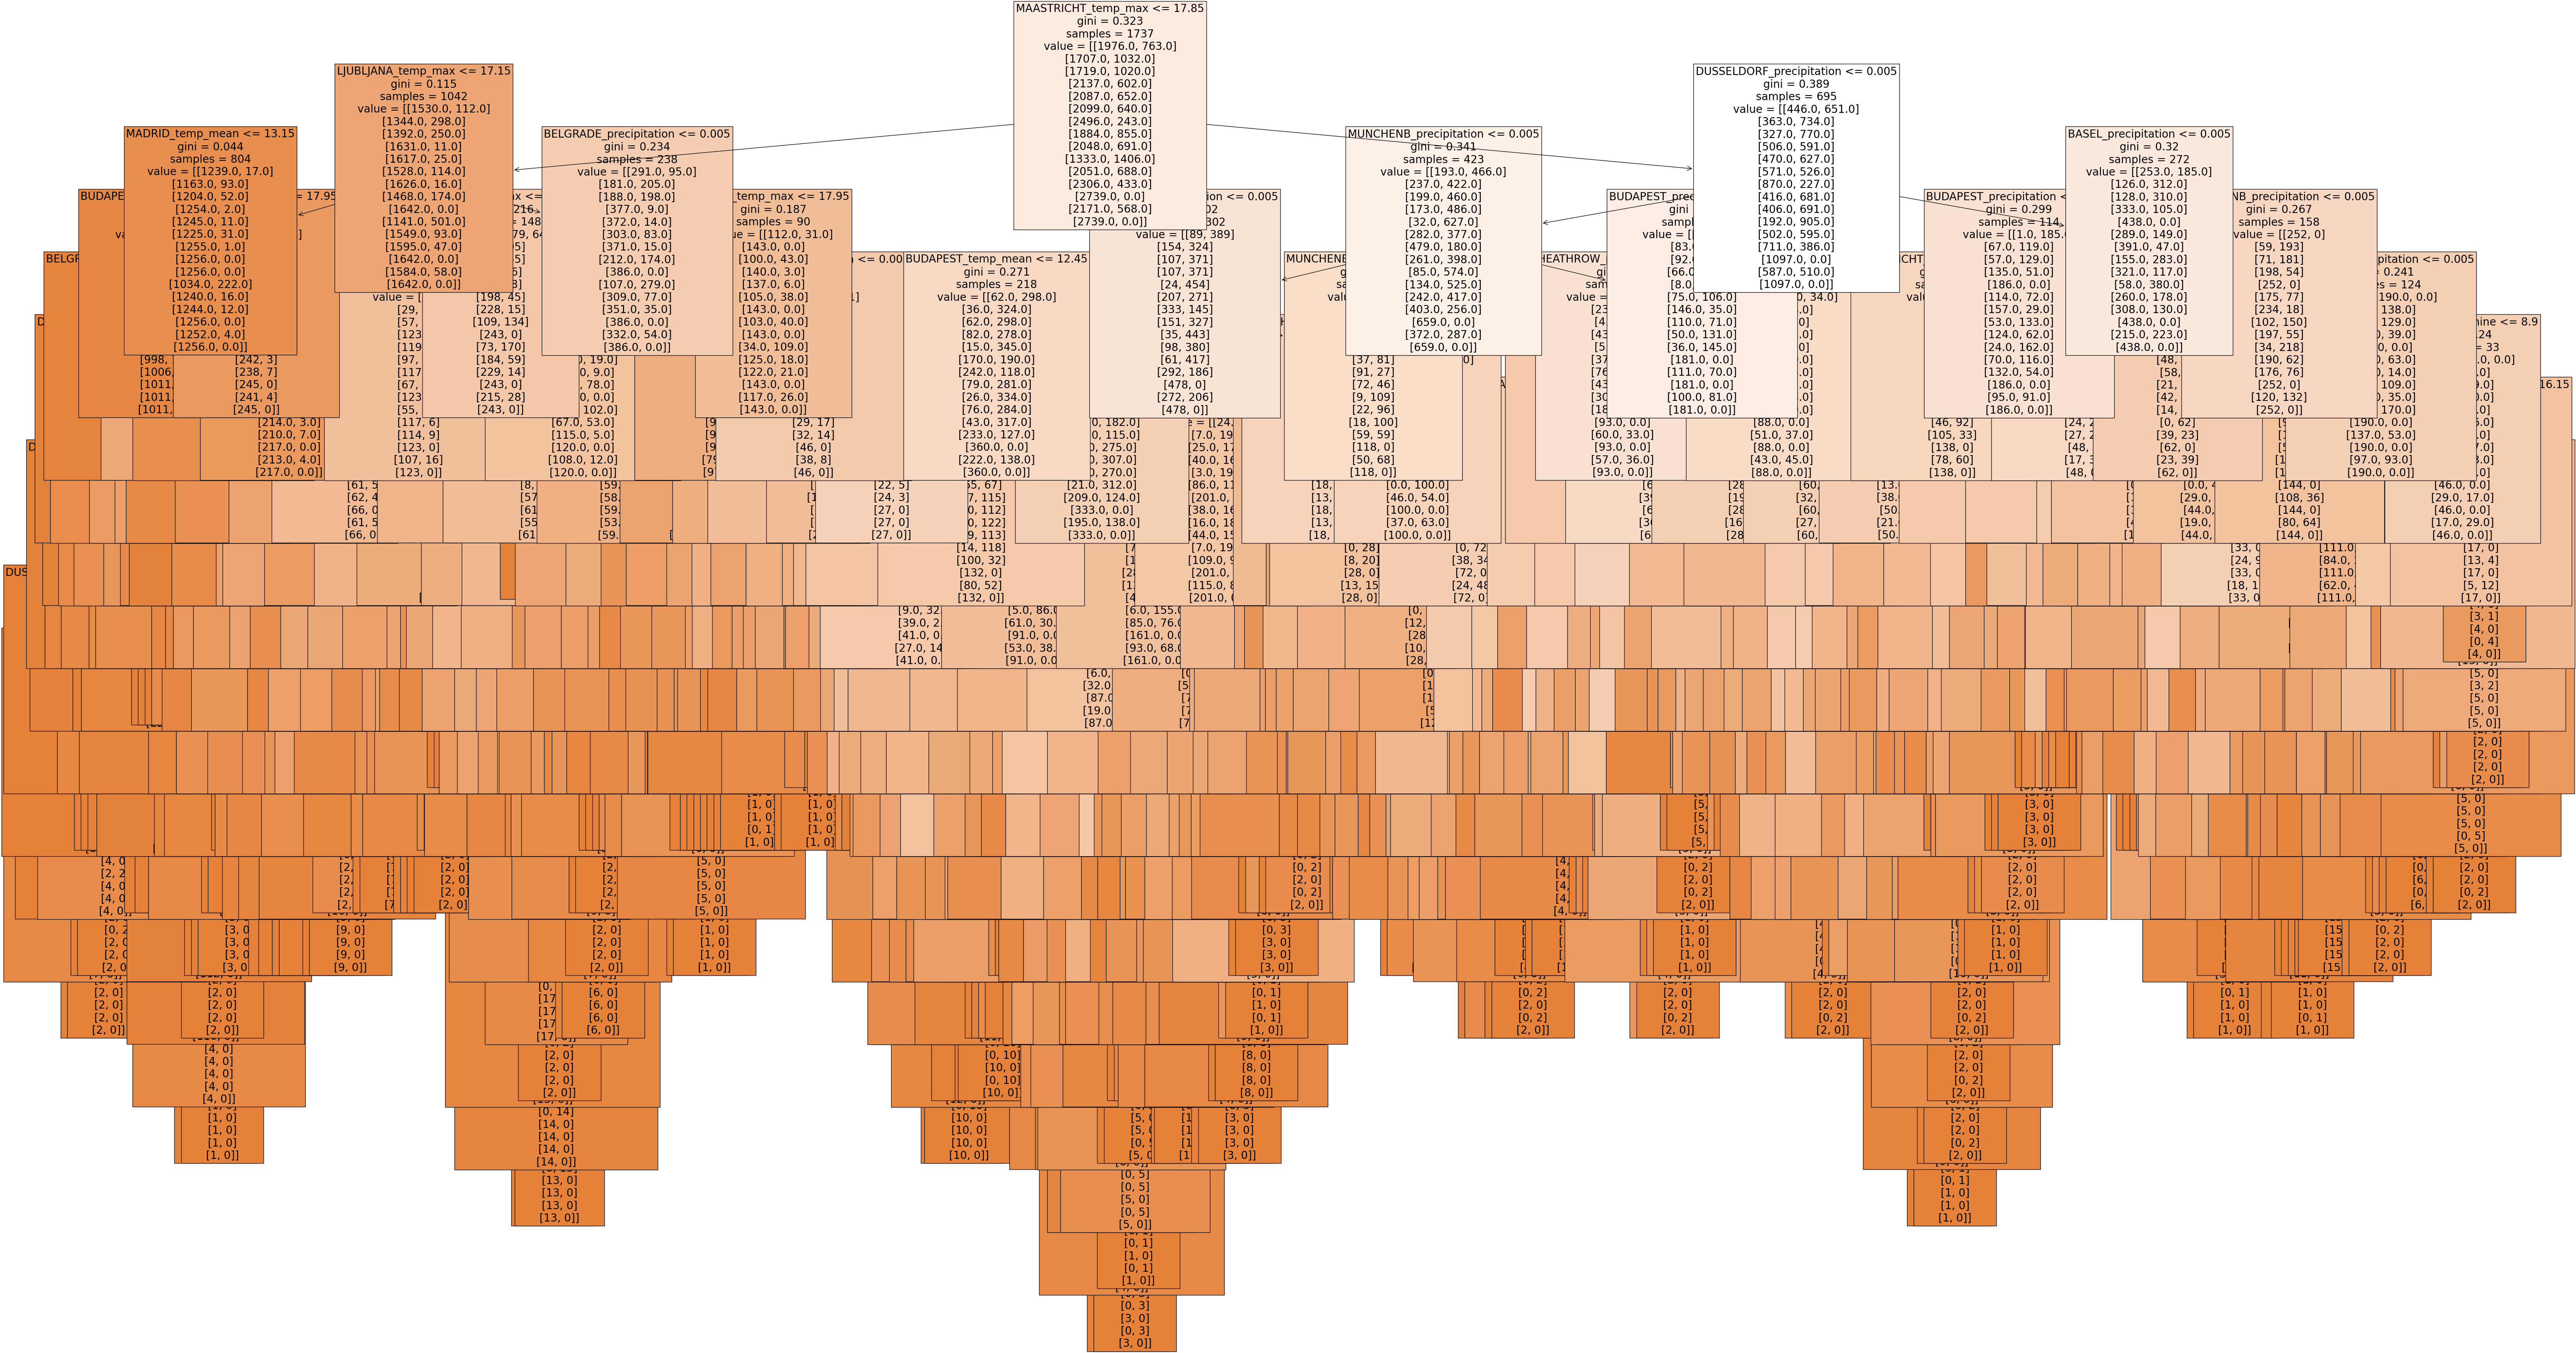

In [87]:
fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[15], fontsize = 20, feature_names = clean_2010.columns, class_names=['unpleasant', 'pleasant'], filled=True);

# 7. Feature Importances

In [90]:
# Retrieve feature importances from the trained model

feature_importances_1 = clf3.feature_importances_
print(clf3.feature_importances_.shape)
feature_importances_1

(135,)


array([1.95644838e-03, 2.29042798e-03, 2.11607503e-03, 2.14910945e-03,
       2.94906116e-02, 5.44580869e-03, 1.17679084e-02, 1.66073476e-03,
       6.84647600e-02, 2.74152799e-03, 2.60449925e-03, 2.34451682e-03,
       1.84995076e-03, 3.04237466e-02, 2.32399587e-03, 3.15906606e-03,
       1.71695517e-03, 7.94625309e-03, 2.33964068e-04, 0.00000000e+00,
       0.00000000e+00, 8.58534017e-04, 2.73057427e-02, 9.37123155e-04,
       9.91539568e-03, 2.13451826e-03, 1.89786012e-02, 1.28545968e-03,
       1.93396986e-03, 2.18139688e-03, 2.49967157e-03, 1.78366959e-02,
       2.41123331e-03, 6.73794460e-03, 1.82156130e-03, 3.46485435e-02,
       1.33810511e-03, 1.68036518e-03, 2.24684869e-03, 2.06821756e-03,
       3.26052738e-02, 2.49105710e-03, 8.22624591e-03, 1.63228201e-03,
       1.19182900e-01, 1.72311138e-03, 2.98819376e-03, 2.17311498e-03,
       2.97782721e-03, 1.31354145e-02, 3.21148159e-03, 2.98578190e-03,
       2.06780821e-03, 9.28546673e-03, 1.69861156e-03, 1.71296412e-03,
      

In [92]:
# Reshaping feature_importances_1

feature_importances_1 = feature_importances_1.reshape(-1,15,9)
print(feature_importances_1.shape)
feature_importances_1

(1, 15, 9)


array([[[1.95644838e-03, 2.29042798e-03, 2.11607503e-03, 2.14910945e-03,
         2.94906116e-02, 5.44580869e-03, 1.17679084e-02, 1.66073476e-03,
         6.84647600e-02],
        [2.74152799e-03, 2.60449925e-03, 2.34451682e-03, 1.84995076e-03,
         3.04237466e-02, 2.32399587e-03, 3.15906606e-03, 1.71695517e-03,
         7.94625309e-03],
        [2.33964068e-04, 0.00000000e+00, 0.00000000e+00, 8.58534017e-04,
         2.73057427e-02, 9.37123155e-04, 9.91539568e-03, 2.13451826e-03,
         1.89786012e-02],
        [1.28545968e-03, 1.93396986e-03, 2.18139688e-03, 2.49967157e-03,
         1.78366959e-02, 2.41123331e-03, 6.73794460e-03, 1.82156130e-03,
         3.46485435e-02],
        [1.33810511e-03, 1.68036518e-03, 2.24684869e-03, 2.06821756e-03,
         3.26052738e-02, 2.49105710e-03, 8.22624591e-03, 1.63228201e-03,
         1.19182900e-01],
        [1.72311138e-03, 2.98819376e-03, 2.17311498e-03, 2.97782721e-03,
         1.31354145e-02, 3.21148159e-03, 2.98578190e-03, 2.06780821

In [94]:
# Collapsing the shape into one observation for each weather station

fisum = np.sum(feature_importances_1[0], axis=1)
fisum

array([0.12534188, 0.05511051, 0.06036388, 0.07135648, 0.1714713 ,
       0.0405482 , 0.02585321, 0.07833357, 0.13251606, 0.07256878,
       0.06729628, 0.04010666, 0.01644513, 0.04009617, 0.00259189])

In [96]:
# Extracting the stations list

stations = [col.split('_')[0] for col in clean_2010.columns if '_' in col]

In [98]:
# Creating a set of unique station names

unique_stations = set(stations)
unique_stations

{'BASEL',
 'BELGRADE',
 'BUDAPEST',
 'DEBILT',
 'DUSSELDORF',
 'HEATHROW',
 'KASSEL',
 'LJUBLJANA',
 'MAASTRICHT',
 'MADRID',
 'MUNCHENB',
 'OSLO',
 'SONNBLICK',
 'STOCKHOLM',
 'VALENTIA'}

In [100]:
# Converting the set of unique stations into a list

unique_stations_list = list(unique_stations)

In [106]:
importance = pd.Series(fisum, index = unique_stations_list)
importance = importance.sort_values(ascending = False)
importance

DEBILT        0.171471
OSLO          0.132516
MAASTRICHT    0.125342
LJUBLJANA     0.078334
SONNBLICK     0.072569
MADRID        0.071356
VALENTIA      0.067296
DUSSELDORF    0.060364
MUNCHENB      0.055111
HEATHROW      0.040548
KASSEL        0.040107
BELGRADE      0.040096
BASEL         0.025853
STOCKHOLM     0.016445
BUDAPEST      0.002592
dtype: float64

In [108]:
# Creating a dataframe to associate weather stations with their importances

df_importance = pd.DataFrame({
    'Weather Station': unique_stations_list,
    'Importances': fisum
})

df_importance = df_importance.sort_values(by='Importances', ascending = False)

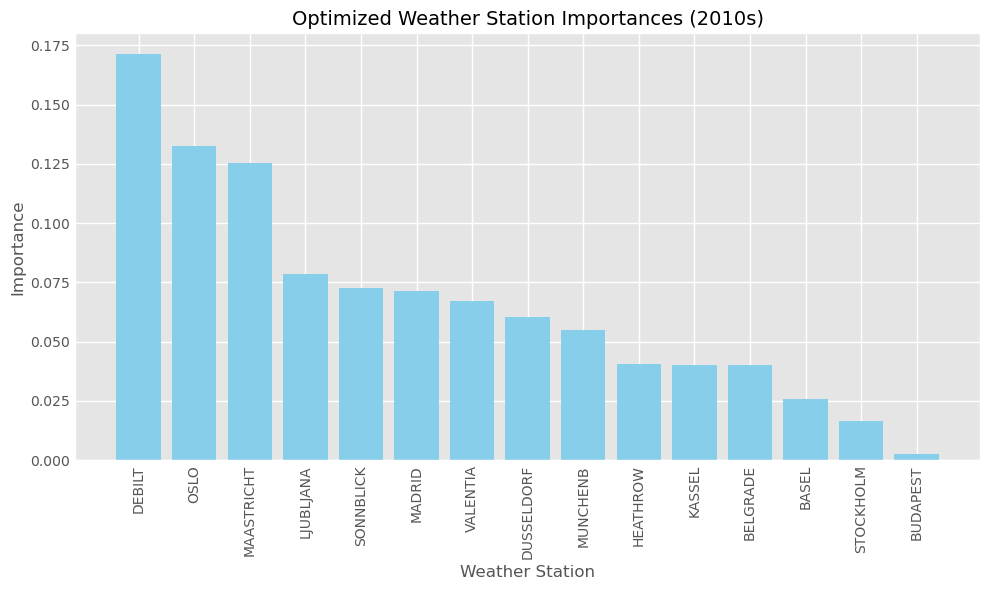

In [117]:
# Plotting the results

%matplotlib inline

plt.style.use('ggplot')
plt.figure(figsize=(10, 6))
plt.bar(df_importance['Weather Station'], df_importance['Importances'], orientation = 'vertical', color='skyblue')
plt.xticks(rotation='vertical')
plt.xlabel('Weather Station', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title('Optimized Weather Station Importances (2010s)', fontsize=14)
plt.tight_layout()

plt.show()